# Mini Project II - Rotten Tomatoes vs Box Office

Members:
- Anh Nguyen
- Kris Nguyen

## Introduction
Movies are often judged based on ideas and comments from critics and the audience themselves. However, whether those *scores* are fully able to determine whether the films will be a huge success or not is inconclusive.
<br><br>
By combining the datasets, we will analyze trends and relationships between *Rotten Tomatoes* scores and their *box office revenues* through different films in [year]. Through this project, we will pinpoint whether these two correlate to each other, in other words, do higher-rated films will be equivalent to higher box office.

### Data Preparation

In [36]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# load datasets
ratings    = pd.read_csv("rotten_tomatoes.csv")
box_office = pd.read_csv("box_office.csv")

In [38]:
# extract and create a new column 'Year' for 'ratings'
ratings['releaseDateTheaters'] = pd.to_datetime(ratings['releaseDateTheaters'])
ratings['Year'] = ratings['releaseDateTheaters'].dt.year

In [39]:
# merge datasets through titles and release year
df = pd.merge(
    ratings,
    box_office,
    left_on=['title', 'Year'],
    right_on=['Release Group', 'Year']
)

### Data Cleaning

In [40]:
# drop rows with NA values
df = df.dropna(subset=['tomatoMeter', '$Worldwide'])

In [41]:
# keep only the columns that we'll be working with
df = df[['title', 'Year', 'tomatoMeter', '$Worldwide']]

### At first glance

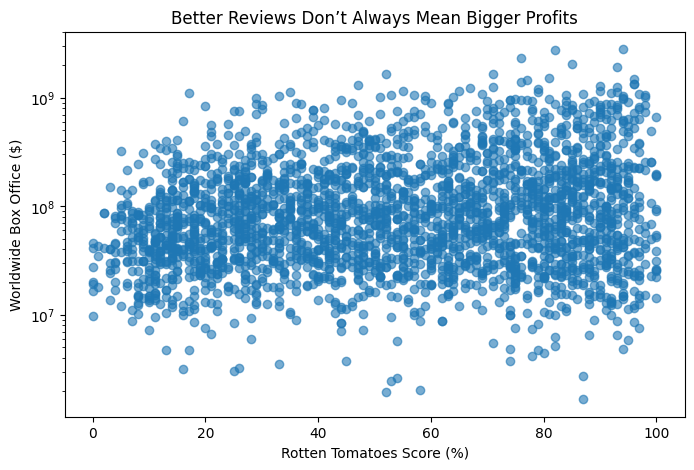

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['tomatoMeter'], df['$Worldwide'], alpha=0.6)

plt.xlabel("Rotten Tomatoes Score (%)")
plt.ylabel("Worldwide Box Office ($)")
plt.title("Better Reviews Don’t Always Mean Bigger Profits")

plt.yscale('log') 
plt.show()

In [43]:
bins = [0, 50, 75, 100]
labels = ['Low', 'Medium', 'High']

df['rating_group'] = pd.cut(df['tomatoMeter'], bins=bins, labels=labels)

grouped = df.groupby('rating_group')['$Worldwide'].mean()

/var/folders/n_/z3k6p59n04s5zn2_bw06m2_h0000gn/T/ipykernel_48890/3584954932.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('rating_group')['$Worldwide'].mean()


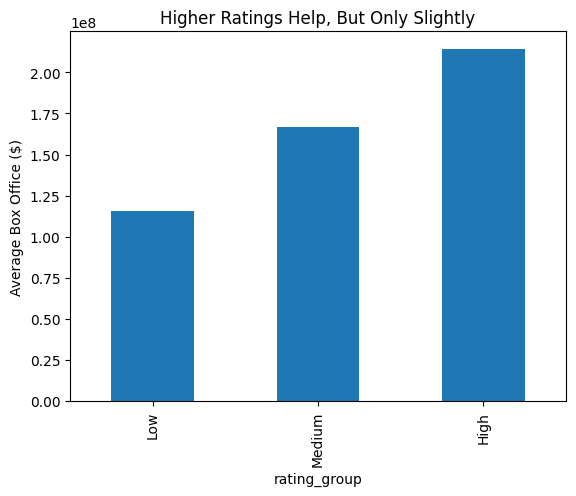

In [45]:
grouped.plot(kind='bar')

plt.ylabel("Average Box Office ($)")
plt.title("Higher Ratings Help, But Only Slightly")
plt.show()